# Modèle LOF (Local Outlier Factor)

Entraîner un modèle LOF sur les features préparées. Visualiser les scores d'anomalie. Comparer les trois approches (Isolation Forest, One-Class SVM, LOF) côte à côte.

## Définition

Le Local Outlier Factor (LOF) est un algorithme de détection d'anomalies non supervisé basé sur la densité locale des points. Contrairement à l'Isolation Forest qui cherche à isoler les anomalies, le LOF compare la densité d'un point avec celle de ses voisins les plus proches. Un point entouré de voisins très proches les uns des autres mais lui-même éloigné de ses voisins aura un score LOF élevé et sera considéré comme une anomalie.

## Principe de l'algorithme

L'algorithme fonctionne en trois étapes :

- **Recherche des voisins** : pour chaque point, on identifie ses k voisins les plus proches dans l'espace de features.
- **Calcul de la densité locale** : on mesure à quel point un point est proche de ses voisins comparé à la proximité que ces voisins ont entre eux.
- **Score LOF** : si un point est dans une zone peu dense entourée de zones denses, son score LOF sera supérieur à 1 — plus le score est élevé, plus le point est anormal. Un score proche de 1 indique un comportement normal.

## Paramètres clés utilisés

- **n_neighbors** : le nombre de voisins à considérer pour calculer la densité locale. Un k trop petit rend le modèle sensible au bruit, un k trop grand le rend trop global.
- **contamination** : la proportion d'anomalies attendues dans le dataset, équivalent au paramètre du même nom dans l'Isolation Forest.
- **novelty=True** : permet d'utiliser le LOF pour prédire sur de nouveaux points (mode prédiction), sinon il ne fonctionne qu'en mode détection sur les données d'entraînement.

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS,low_memory=False)



## Dataset 1 : CIC-IDS-2017

### 1.1 Préparation des données

Comme pour le One-Class SVM, on travaille sur un échantillon de 10 000 points pour garder la proportion réelle d'attaques.

In [3]:
from sklearn.model_selection import train_test_split  # pour créer un échantillon avec la même proportion

X = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])  # on garde uniquement les colonnes numériques sans le label
y = (df_cicids['Label'] != 'BENIGN').astype(int)  # 0 pour normal et  1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # on remplace les valeurs manquantes et infinies par 0
X_scaled = StandardScaler().fit_transform(X)  # normalisation donc met toutes les features à la même échelle
X_cicids_sample, _, y_cicids_sample, _ = train_test_split(X_scaled, y, train_size=10000, stratify=y, random_state=42) # on garde 10 000 points en respectant les proportions des classes (stratify=y)

print(f"Taille échantillon : {X_cicids_sample.shape}")       
print(f"Proportion d'attaques : {y_cicids_sample.mean():.2%}") 

Taille échantillon : (10000, 79)
Proportion d'attaques : 57.38%


### 1.2 Entraînement LOF et comparaison des trois modèles

In [4]:
# LOF
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.50) #20 plus proches voisins et proportions d'attaques environ 50%
pred_lof = (lof.fit_predict(X_cicids_sample) == -1).astype(int) #1 si anomalie et 0 si normal
score_lof = -lof.negative_outlier_factor_  # score positif 
t_lof = time.time() - t0 #temps final

# One-Class SVM 
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.50, gamma='scale')
pred_svm = (svm.fit_predict(X_cicids_sample) == -1).astype(int)
t_svm = time.time() - t0

# Isolation Forest
t0 = time.time()
iforest = IsolationForest(contamination=0.50, random_state=42, n_jobs=-1)
pred_if = (iforest.fit_predict(X_cicids_sample) == -1).astype(int)
score_if = -iforest.score_samples(X_cicids_sample) 
t_if = time.time() - t0 #temps final

print(f"Temps LOF : {t_lof:.2f}s")
print(f"Temps One-Class SVM : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")
print(classification_report(y_cicids_sample, pred_lof, target_names=['Normal', 'Attaque']))
print(classification_report(y_cicids_sample, pred_svm, target_names=['Normal', 'Attaque']))
print(classification_report(y_cicids_sample, pred_if, target_names=['Normal', 'Attaque']))

Temps LOF : 1.53s
Temps One-Class SVM : 34.49s
Temps Isolation Forest : 0.73s
              precision    recall  f1-score   support

      Normal       0.41      0.48      0.44      4262
     Attaque       0.55      0.48      0.51      5738

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.48     10000
weighted avg       0.49      0.48      0.48     10000

              precision    recall  f1-score   support

      Normal       0.23      0.28      0.25      4262
     Attaque       0.38      0.33      0.36      5738

    accuracy                           0.31     10000
   macro avg       0.31      0.30      0.30     10000
weighted avg       0.32      0.31      0.31     10000

              precision    recall  f1-score   support

      Normal       0.31      0.36      0.33      4262
     Attaque       0.45      0.40      0.42      5738

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.38     10

On remarque que le temps LOF est le plus rapide des trois avec seulement 1.53s devant l'Isolation Forest 0.73s et devant le One-Class SVM 34.49s. 
Concernant les performances le LOF obtient les meilleurs résultats avec un f1 de 0.51 sur les attaques, contre 0.36 pour le SVM et 0.42 pour l'Isolation Forest. Ainsi il s'agit du seul modèle qui dépasse 0.50 sur ce dataset. Cela peut s'expliquer par la nature des attaques dans CICIDS car les attaques DDoS forment des groupes denses très différents du trafic normal en termes de densité locale, ce qui est exactement ce que le LOF est conçu à détecter. 

### 1.3 Visualisation des scores d'anomalie

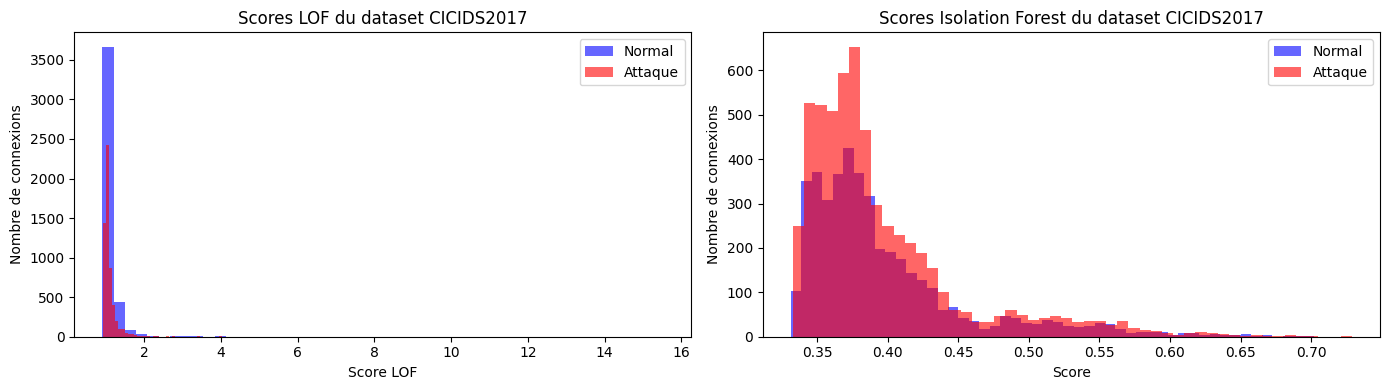

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Score Anomalie LOF
for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Attaque']):
    ax1.hist(score_lof[y_cicids_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax1.set(title='Scores LOF du dataset CICIDS2017', xlabel='Score LOF', ylabel='Nombre de connexions')
ax1.legend()

# Score Anomalie Isolation Forest
for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Attaque']):
    ax2.hist(score_if[y_cicids_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax2.set(title='Scores Isolation Forest du dataset CICIDS2017', xlabel='Score', ylabel='Nombre de connexions')
ax2.legend()
plt.tight_layout()
plt.show()

Pour le graphe de l'algorithme LOF, presque tous les points sont concentrés à un score proche de 0. Les deux distributions sont totalement superposées ce qui confirme que le LOF ne distingue pas bien les attaques des connexions normales sur ce dataset malgré un f1 légèrement meilleur.
Pour le graphe de l'Isolation Forest on voit une légère séparation entre les deux distributions entre les attaques (rouge) qui sont légèrement plus concentrées vers les scores bas (0.35-0.40) tandis que les normaux s'étalent davantage vers les scores plus élevés. Ce n'est pas une séparation nette mais elle est plus visible que pour le LOF.

### 1.4 Matrices de confusion comparées

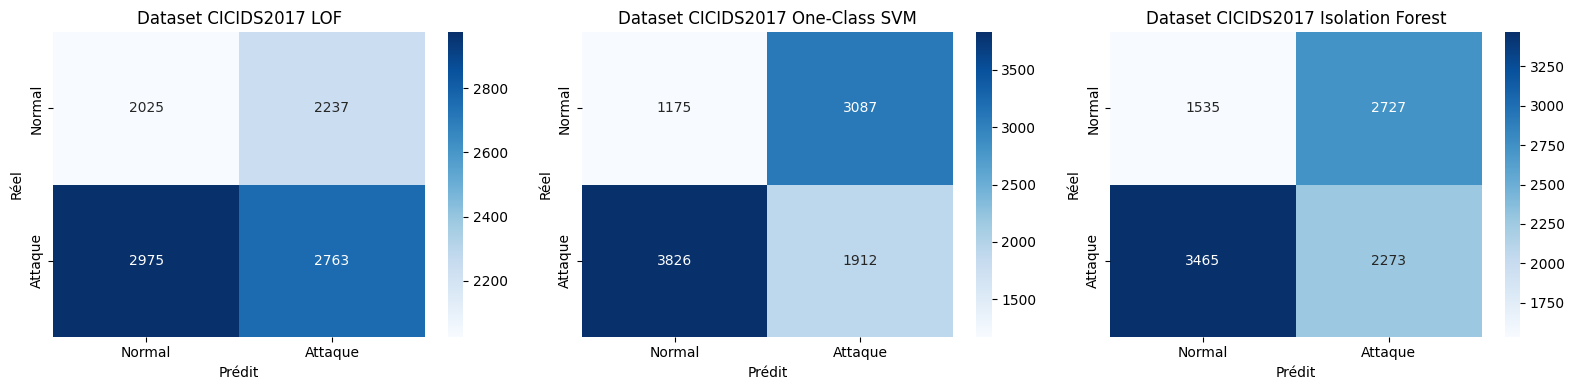

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, pred, title in zip(axes, [pred_lof, pred_svm, pred_if], ['LOF', 'One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_cicids_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
    ax.set(title=f'Dataset CICIDS2017 {title}', xlabel='Prédit', ylabel='Réel')

plt.tight_layout()
plt.show()

Les trois matrices confirment que le LOF est le meilleur modèle sur CICIDS avec 2 763 attaques détectées sur 5 738, contre 1912 pour le One-Classe SVM et 2273 pour l'Isolation Forest. De même le LOF génère moins de faux positifs avec 2 237 normaux faussement signalés contre 3 087 pour le SVM et 2 727 pour l'Isolation Forest. Il s'agit dpnc du meilleur algorithme des trois.


## Dataset 2 : UNSW-NB15

### 2.1 Préparation des données

In [7]:
# préparation features / label
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label']  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # remplace valeurs manquantes et infinies par 0
X_unsw_scaled = StandardScaler().fit_transform(X)  # normalisation

# échantillon stratifié de 10 000 points
X_unsw_sample, _, y_unsw_sample, _ = train_test_split(X_unsw_scaled, y_unsw, train_size=10000, stratify=y_unsw, random_state=42)

print(f"Taille échantillon : {X_unsw_sample.shape}")
print(f"Proportion d'attaques : {y_unsw_sample.mean():.2%}")

Taille échantillon : (10000, 44)
Proportion d'attaques : 3.17%


### 2.2 Entraînement LOF et comparaison des trois modèles

In [8]:
# LOF
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
pred_lof = (lof.fit_predict(X_unsw_sample) == -1).astype(int)
score_lof = -lof.negative_outlier_factor_
t_lof = time.time() - t0

# One-Class SVM
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.03, gamma='scale')
pred_svm = (svm.fit_predict(X_unsw_sample) == -1).astype(int)
t_svm = time.time() - t0

# Isolation Forest
t0 = time.time()
iforest = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
pred_if = (iforest.fit_predict(X_unsw_sample) == -1).astype(int)
score_if = -iforest.score_samples(X_unsw_sample)
t_if = time.time() - t0

print(f"Temps LOF : {t_lof:.2f}s")
print(f"Temps One-Class SVM  : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")
print(classification_report(y_unsw_sample, pred_lof, target_names=['Normal', 'Attaque']))
print(classification_report(y_unsw_sample, pred_svm, target_names=['Normal', 'Attaque']))
print(classification_report(y_unsw_sample, pred_if, target_names=['Normal', 'Attaque']))

Temps LOF : 0.73s
Temps One-Class SVM  : 2.23s
Temps Isolation Forest : 0.56s
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      9683
     Attaque       0.18      0.17      0.18       317

    accuracy                           0.95     10000
   macro avg       0.58      0.57      0.58     10000
weighted avg       0.95      0.95      0.95     10000

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9683
     Attaque       0.25      0.24      0.25       317

    accuracy                           0.95     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.95      0.95      0.95     10000

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9683
     Attaque       0.34      0.32      0.33       317

    accuracy                           0.96     10000
   macro avg       0.66      0.65      0.65     10

Sur ce dataset UNSW-NB15 c'est l'Isolation Forest qui s'impose avec le meilleur f1 sur les attaques (0.33) contre 0.25 pour le SVM et seulement 0.18 pour le LOF .
Concernant le temps le LOF (0.73s) et l'Isolation Forest (0.56s) sont plus rapides que le SVM (2.23s).
Le LOF déçoit sur ce dataset car les attaques UNSW sont rares et dispersées (seulement 317 sur 10 000 points) en effet les attaques ne forment pas de groupes denses distincts du trafic normal ce qui est l'inverse du dataset CICIDS où le LOF était le plus performant justement grâce aux groupes denses d'attaques DDoS. Ainsi selon le contexte un algorithme.

### 2.3 Visualisation des scores d'anomalie

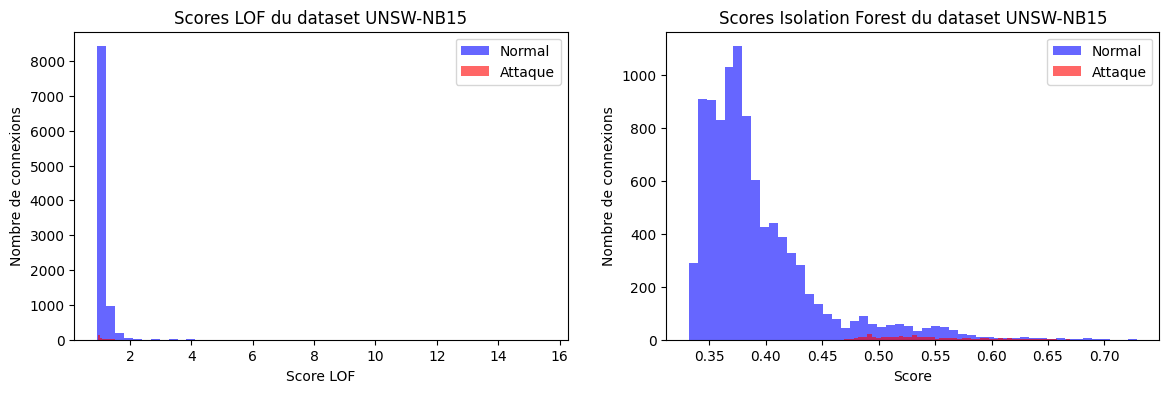

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Attaque']):
    ax1.hist(score_lof[y_unsw_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax1.set(title='Scores LOF du dataset UNSW-NB15', xlabel='Score LOF', ylabel='Nombre de connexions')
ax1.legend()

for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Attaque']):
    ax2.hist(score_if[y_unsw_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax2.set(title='Scores Isolation Forest du dataset UNSW-NB15', xlabel='Score', ylabel='Nombre de connexions')
ax2.legend()

plt.show()

On remarque que pour l'algorithme LOF les distributions Normal et Attaque sont presque identiques toutes deux sont concentrées autour d'un score de 1 à 2, avec quelques rares points atteignant des scores élevés. Le pic d'attaque à lieu au même score que le pic de normaux ce qui ne permet donc pas de les distinguer convenablement.
Pour l'Isolation Forest, bien que les attaques soient très peu nombreuses et donc peu visibles, on distingue qu'elles se concentrent légèrement vers les scores plus élevés (0.50-0.70) par rapport aux normaux qui s'accumulent vers 0.35-0.45. Cette légère séparation suffit à l'Isolation Forest pour obtenir de meilleures performances que le LOF sur ce dataset.

### 2.4 Matrices de confusion comparées

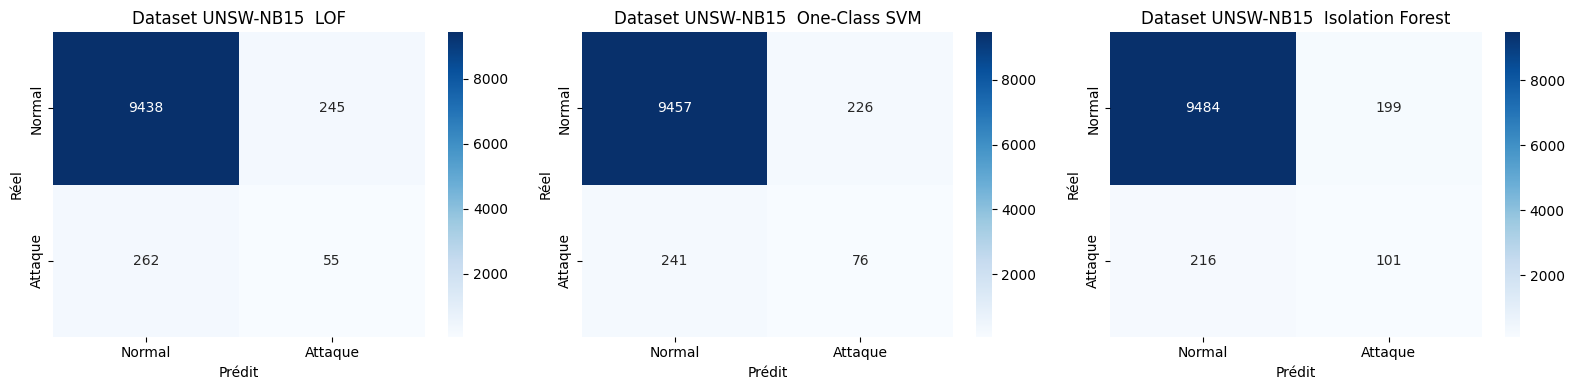

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, pred, title in zip(axes,
                           [pred_lof, pred_svm, pred_if],
                           ['LOF', 'One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_unsw_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
    ax.set(title=f'Dataset UNSW-NB15  {title}', xlabel='Prédit', ylabel='Réel')

plt.tight_layout()
plt.show()

On remarques sur les 317 attaques réelles l'Isolation Forest en détecte 101, le SVM 76 et le LOF seulement 55 ainsi l'Isolation Forest est clairement le meilleur des trois sur le dataset UNSW. En revanche les trois modèles se valent sur les connexions normales avec très peu de faux positifs : 245 pour le LOF, 226 pour le SVM et seulement 199 pour l'Isolation Forest qui est donc le plus précis sur les deux tableaux. Sur ce dataset où les attaques sont rares et dispersées, l'Isolation Forest s'impose comme le meilleur des algorithme.


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Préparation des données

In [13]:
# encodage des colonnes texte en nombres
df_enc = df_logs.copy()
for col in ['protocol', 'action', 'log_type']:
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))

# sélection des features et normalisation
features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')]
X = df_enc[features].fillna(0)
y = (df_logs['threat_label'] != 'benign').astype(int)  # 0 pour normal et 1 pour anomalie
X_logs_scaled = StandardScaler().fit_transform(X)


X_logs_sample, _, y_logs_sample, _ = train_test_split( X_logs_scaled, y, train_size=10000, stratify=y, random_state=42) # echantillon stratifié de 10 000 points

print(f"Taille échantillon : {X_logs_sample.shape}")
print(f"Proportion d'anomalies : {y_logs_sample.mean():.2%}")

Taille échantillon : (10000, 4)
Proportion d'anomalies : 8.04%


### 3.2 Entraînement LOF et comparaison des trois modèles

In [14]:
# LOF
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.08)
pred_lof = (lof.fit_predict(X_logs_sample) == -1).astype(int)
score_lof = -lof.negative_outlier_factor_
t_lof = time.time() - t0

# One-Class SVM
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.08, gamma='scale')
pred_svm = (svm.fit_predict(X_logs_sample) == -1).astype(int)
t_svm = time.time() - t0

# Isolation Forest
t0 = time.time()
iforest = IsolationForest(contamination=0.08, random_state=42, n_jobs=-1)
pred_if = (iforest.fit_predict(X_logs_sample) == -1).astype(int)
score_if = -iforest.score_samples(X_logs_sample)
t_if = time.time() - t0

print(f"Temps LOF : {t_lof:.2f}s")
print(f"Temps One-Class SVM : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")
print(classification_report(y_logs_sample, pred_lof, target_names=['Normal', 'Anomalie']))
print(classification_report(y_logs_sample, pred_svm, target_names=['Normal', 'Anomalie']))
print(classification_report(y_logs_sample, pred_if, target_names=['Normal', 'Anomalie']))

Temps LOF : 0.46s
Temps One-Class SVM : 1.98s
Temps Isolation Forest : 0.67s
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      9196
    Anomalie       0.12      0.12      0.12       804

    accuracy                           0.86     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.86      0.86      0.86     10000

              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      9196
    Anomalie       0.08      0.08      0.08       804

    accuracy                           0.85     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.85      0.85      0.85     10000

              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      9196
    Anomalie       0.10      0.10      0.10       804

    accuracy                           0.86     10000
   macro avg       0.51      0.51      0.51     100

Sur le dataset Logs les trois modèles donnent des résultats quasi identiques mauvais avec un f1 de 0.12 pour le LOF, 0.08 pour le SVM et 0.10 pour l'Isolation Forest. Aucun ne parvient à détecter correctement les anomalies. Concernant le temps, le LOF est le plus rapide (0.46s) devant l'Isolation Forest (0.67s) et le SVM (1.98s).
Ce résultat confirme une fois de plus que le problème vient des données et non des algorithmes car avec seulement 4 features peu discriminantes, aucun modèle ne peut faire mieux, peu importe son approche.

### 3.3 Visualisation des scores d'anomalie

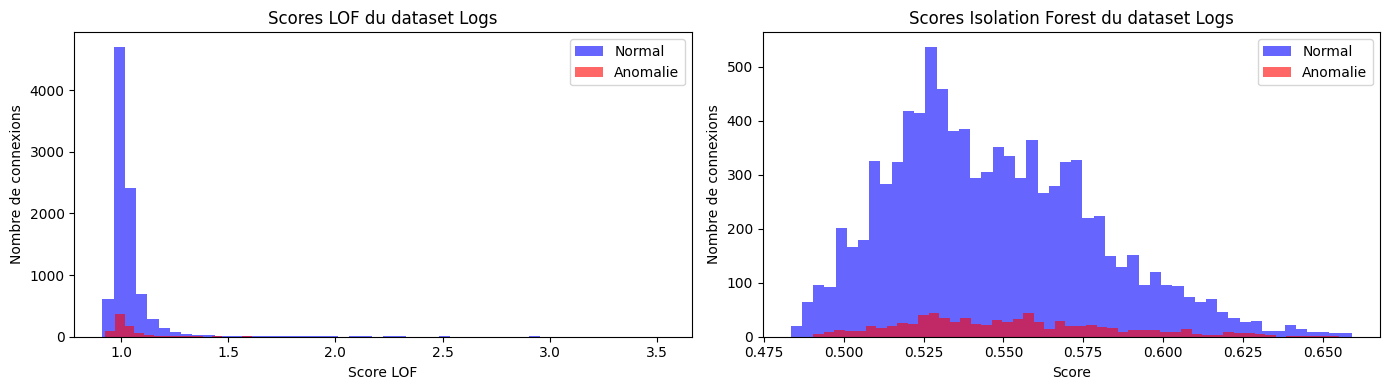

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Anomalie']):
    ax1.hist(score_lof[y_logs_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax1.set(title='Scores LOF du dataset Logs', xlabel='Score LOF', ylabel='Nombre de connexions')
ax1.legend()

for label, color, name in zip([0, 1], ['blue', 'red'], ['Normal', 'Anomalie']):
    ax2.hist(score_if[y_logs_sample == label], bins=50, alpha=0.6, label=name, color=color)
ax2.set(title='Scores Isolation Forest du dataset Logs', xlabel='Score', ylabel='Nombre de connexions')
ax2.legend()

plt.tight_layout()
plt.show()

Pour le graphe de l'algorithme LOF, les anomalies (rouge) et les normaux (violet) sont entièrement superposés autour d'un score de 1.0 ainsi le modèle n'attribue aucun score distinctif aux anomalies, elles sont invisibles parmi les connexions normales. Pour l'Isolation Forest, c'est identique car les deux distributions se chevauchent complètement entre 0.50 et 0.65, sans aucune séparation visible. 

### 3.4 Matrices de confusion comparées

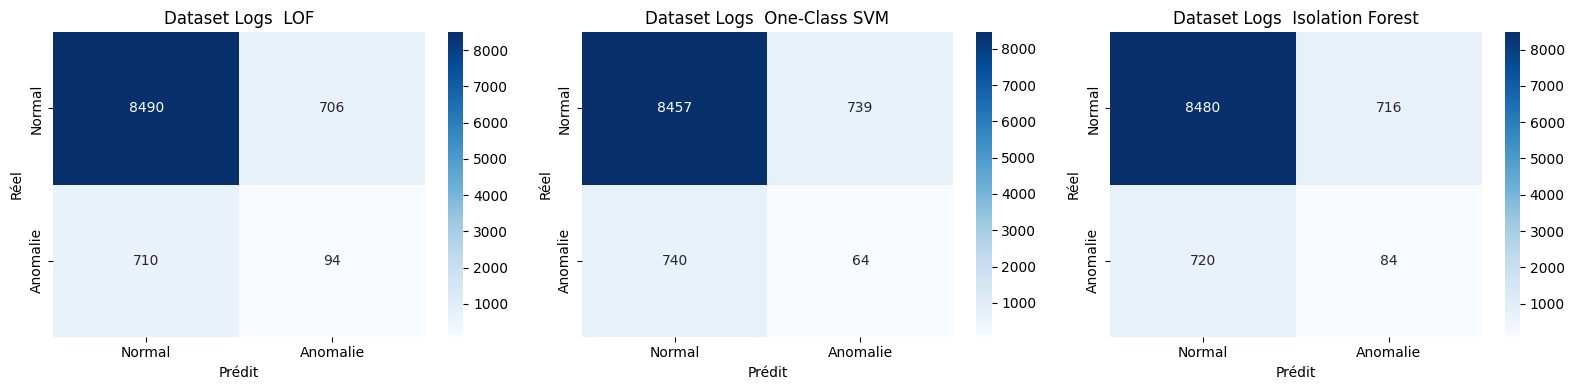

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, pred, title in zip(axes,
                           [pred_lof, pred_svm, pred_if],
                           ['LOF', 'One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_logs_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
    ax.set(title=f'Dataset Logs  {title}', xlabel='Prédit', ylabel='Réel')

plt.tight_layout()
plt.show()

Les trois matrices sont presque identiques, ce qui confirme que les trois modèles se comportent de la même façon sur ce dataset. Sur les 804 anomalies réelles, le LOF en détecte 94, l'Isolation Forest 84 et le SVM seulement 64 ainsi le LOF est donc légèrement meilleur .
Les faux positifs sont également similaires avec environ 700-740 connexions normales faussement signalées pour les trois modèles. Aucun ne se démarque vraiment, ce qui confirme que le problème est inhérent aux données et non au choix de l'algorithme.


## Bilan comparatif des trois modèles

En conlusion sur le dataset CICIDS2017, l'algorithme LOF obtient les meilleures performances (f1 = 0.51) car les attaques DDoS forment des groupes denses que la comparaison de densité locale détecte bien. Sur le dataset UNSW-NB15 en revanche, l'Isolation Forest est meilleur (f1 = 0.33) car les attaques y sont rares et isolées, ce qui correspond exactement au principe de cet algorithme. Sur le dataset Logs enfin, les trois modèles échouent de façon identique avec des f1 inférieurs à 0.12 cela provenant de la limite venant clairement du manque de features discriminantes plutôt que du choix de l'algorithme.
En termes de temps on remarque que l'algorithme One-Class SVM est systématiquement le plus lent et pourtant il n'obtient jamais les meilleures performances. Entre le LOF et l'Isolation Forest, le choix dépend du type d'anomalies attendues selon si les attaques sont groupées et denses alors LOF sera plus performant ou si les attaques sont rares et isolées on choisira l'algorithme Isolation Forest.